# Transforms

> Data transformations and augmentations for 2D and 3D BioImages

In [ ]:
#| default_exp transforms

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| export
from fastai.vision.all import *
from fastai.data.all import *
from monai.transforms import SpatialCrop, Flip, Rotate90, Spacing
from numpy import percentile, isscalar, float32 as np_float32

## Sampling

In [ ]:
#| export
class Resample(Spacing):
    """
    A subclass of Spacing that handles image resampling based on specified sampling factors or voxel dimensions.
    
    The `Resample` class inherits from `Spacing` and provides a flexible way to adjust the spacing (voxel size) of images by specifying either a sampling factor or explicitly providing new voxel dimensions.
    
    Args:
        sampling (int, optional): Sampling factor for isotropic resampling. Default is 1, indicating no change in resolution.
        **kwargs: Additional keyword arguments that can include 'pixdim' to specify custom voxel dimensions.
        
    Attributes:
        pixdim (list or tuple): The voxel dimensions of the image after resampling. If not provided during initialization, this will be determined based on the sampling factor and original image properties.
    
    Methods:
        None
    
    Example Usage:
        # Creating a Resample object with a specified sampling factor
        resampler = Resample(sampling=2)
        
        # Creating a Resample object with custom voxel dimensions
        resampler = Resample(**kwargs={'pixdim': [1.5, 1.5, 3]})
    """
    
    def __init__(self, sampling, **kwargs):
        """
        Initializes the Resample class instance.
        
        Args:
            sampling (int, optional): Sampling factor for isotropic resampling. Default is 1.
            **kwargs: Additional keyword arguments that can include 'pixdim' to specify custom voxel dimensions.
            
        If 'pixdim' is provided in kwargs, it will be used directly; otherwise, the sampling factor will determine the new voxel dimensions.
        
        The Spacing class from which Resample inherits is initialized with either the provided pixdim or calculated based on the sampling factor and original image properties.
        """
        if 'pixdim' in kwargs:
            super().__init__(**kwargs)
        else:
            super().__init__(sampling, **kwargs)


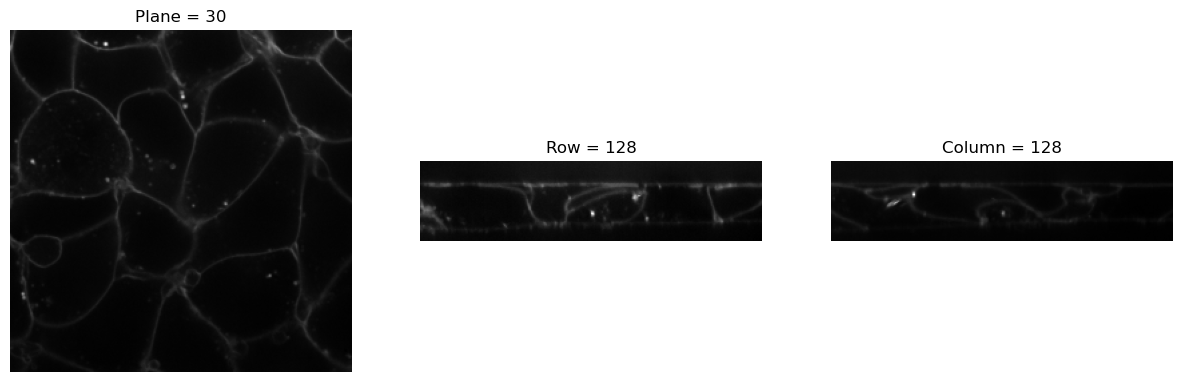

`data_array` is not of type MetaTensor, assuming affine to be identity.


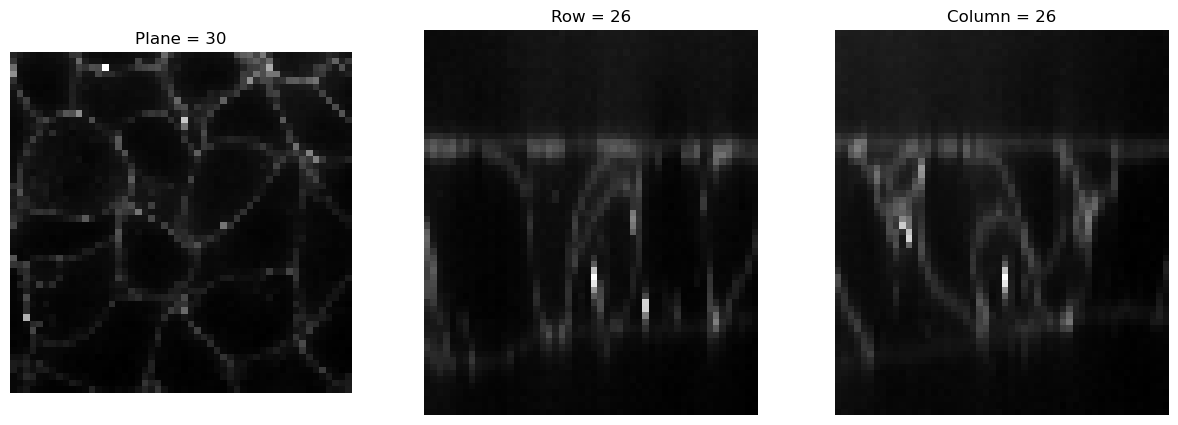

In [ ]:
from bioMONAI.core import cells3d, img2Tensor
from bioMONAI.visualize import visualize_slices


img = cells3d()[:,0]

visualize_slices(img, showlines=False)

img2 = Resample(5)(img2Tensor(img))

visualize_slices(img2, showlines=False)

## Noise

In [ ]:
#| export
def RandCameraNoise(input_image, qe=0.7, gain=2, exp_time=0.1,
                     dark_current=0.06, readout=2.5, bitdepth=16, offset=100,
                     seed=42, simulation = False, camera = 'cmos', gain_variance=.1, offset_variance=5):
 
    # Random state
    rs = np.random.RandomState(seed=seed)
    
    # Add shot noise
    input_photons = input_image if simulation else input_image / gain / qe
    photons = rs.poisson(input_photons, size=input_photons.shape)
    
    # Convert to electrons
    electrons = qe * photons
    
    # Add dark noise
    dark_noise = rs.poisson(dark_current*exp_time, size=electrons.shape)
    electrons += dark_noise
    
    # Add readout noise
    read_noise = rs.normal(scale=readout**2, size=electrons.shape)
    electrons += read_noise
    
    if camera == 'cmos':
        gain = rs.normal(scale=gain_variance, size=electrons.shape) + gain + rs.normal(scale=gain_variance, size=electrons.shape[0])
        fixed_pattern = rs.normal(scale=offset_variance, size=electrons.shape[0])
        offset = rs.normal(scale=offset_variance, size=electrons.shape)+ fixed_pattern + offset
    
    # Convert to ADU and add offset
    max_adu = (2**bitdepth - 1)
    adu = (electrons * gain)
    adu += offset
    adu[adu > max_adu] = max_adu # pixel saturation
    
    # pixel_type = np.uint8 if bitdepth <= 8 else np.uint16
    # adu = adu.astype(pixel_type) # Convert to discrete numbers
    
    return adu

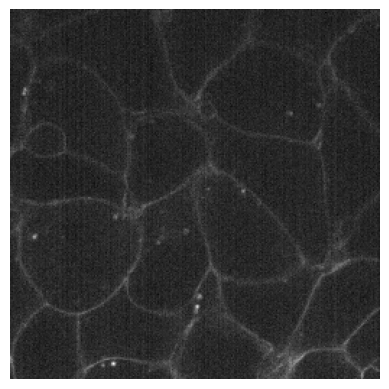

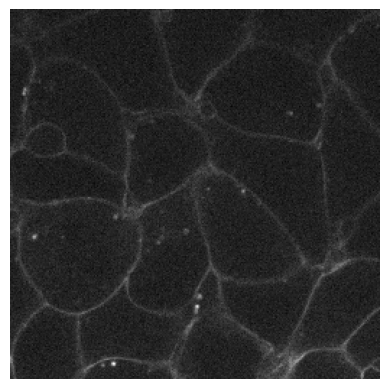

In [ ]:
from bioMONAI.visualize import plot_image

plot_image(RandCameraNoise(.01*img[30], camera = 'cmos'))
plot_image(RandCameraNoise(.01*img[30], camera = 'ccd'))

## Normalization

In [ ]:
#| export
def ScaleIntensityRange(x, mi, ma, eps=1e-20, dtype=np_float32):
    if dtype is not None:
        x = x.astype(dtype, copy=False)
        mi = dtype(mi) if isscalar(mi) else mi.astype(dtype, copy=False)
        ma = dtype(ma) if isscalar(ma) else ma.astype(dtype, copy=False)
        eps = dtype(eps)
        x = (x - mi) / (ma - mi + eps)
    return x

In [ ]:
#| export
def ScaleIntensityPercentiles(x, pmin=3, pmax=99.8, axis=None, eps=1e-20, dtype=np_float32):
    """Percentile-based image normalization."""

    mi = percentile(x, pmin, axis=axis, keepdims=True)
    ma = percentile(x, pmax, axis=axis, keepdims=True)
    return ScaleIntensityRange(x, mi, ma, eps=eps, dtype=dtype)


## Data Augmentation

### Utilities

In [ ]:
# # Define a random tensor
# orig_size = (10, 8)
# rand_tensor = torch.rand(3, *orig_size)  # Random tensor with shape (3, 10, 8)

# # Specify the desired size and top-left corner for cropping
# size = (12, 9)
# tl = (2, 3)

# # Perform cropping
# result_tensor = crop_pad_tensor(rand_tensor, size, tl, orig_size)

# print("Original tensor shape:", rand_tensor.shape)
# print("Cropped tensor shape:", result_tensor.shape)

In [ ]:
#| export

def _process_sz(size, ndim=3):
    if isinstance(size,int): 
        size=(size,)*ndim
    return fastuple(size)

def _get_sz(x):
    if isinstance(x, tuple): x = x[0]
    if not isinstance(x, Tensor): return fastuple(x.size)
    return fastuple(getattr(x, 'img_size', getattr(x, 'sz', (x.shape[1:])))) # maybe it should swap x and y axes 

In [ ]:
# Define a random tensor
orig_size = (10, 8)
rand_tensor = torch.rand(3, *orig_size)  # Random tensor with shape (3, 10, 8)

test_eq((3,)*3,_process_sz(3,ndim=3))
test_eq(orig_size,_get_sz((rand_tensor, rand_tensor)))

### Random Transforms

In [ ]:
#| export

class RandCrop2D(RandTransform):
    "Randomly crop an image to `size`"
    split_idx,order = None,1
    def __init__(self, 
        size:int|tuple, # Size to crop to, duplicated if one value is specified
        lazy = False,   # a flag to indicate whether this transform should execute lazily or not. Defaults to False
        **kwargs
    ):
        size = _process_sz(size, ndim=2)
        store_attr()
        super().__init__(**kwargs)

    def before_call(self, 
        b, 
        split_idx:int # Index of the train/valid dataset
    ):
        "Randomly positioning crop if train dataset else center crop"
        self.orig_sz = _get_sz(b)
        if split_idx: self.ctr = (self.orig_sz)//2
        else:
            wd = self.orig_sz[0] - self.size[0]
            hd = self.orig_sz[1] - self.size[1]
            w_rand = (wd, -1) if wd < 0 else (0, wd)
            h_rand = (hd, -1) if hd < 0 else (0, hd)
            self.ctr = fastuple(random.randint(*w_rand)+self.size[0]//2, random.randint(*h_rand)+self.size[1]//2)

    def encodes(self, x):
        return SpatialCrop(roi_center=self.ctr, roi_size=self.size, lazy=self.lazy)(x)

In [ ]:
#| export

class RandCropND(RandTransform):
    """
    Randomly crops an ND image to a specified size.

    This transform randomly crops an ND image to a specified size during training and performs
    a center crop during validation. It supports both 2D and 3D images and videos, assuming
    the first dimension is the batch dimension.

    Args:
        size (int or tuple): The size to crop the image to. this can have any number of dimensions. 
                             If a single value is provided, it will be duplicated for each spatial 
                             dimension, up to a maximum of 3 dimensions.
        **kwargs: Additional keyword arguments to be passed to the parent class.
    """

    split_idx,order = None,1
        
    def __init__(self, size: int | tuple, # Size to crop to, duplicated if one value is specified
                 lazy = False,            # a flag to indicate whether this transform should execute lazily or not. Defaults to False
                 **kwargs):
        size = _process_sz(size)
        store_attr()
        super().__init__(**kwargs)

    def before_call(self, b, split_idx: int):
        "Randomly position crop if train dataset else center crop"
        self.orig_sz = _get_sz(b)
        if split_idx:
            self.tl = tuple((osz - sz) // 2 for osz, sz in zip(self.orig_sz, self.size))
            self.br = tuple((osz + sz) // 2 for osz, sz in zip(self.orig_sz, self.size))
        else:
            tl = [] # top-left corner
            br = [] # bottom-right corner
            # Calculate top-left and bottom-right corner coordinates for random crop
            for osz, sz in zip(self.orig_sz, self.size):
                w_dif = osz - sz
                if w_dif < 0:
                    w_rand = (0, 0) # No random cropping if input size is smaller than crop size
                    sz = osz # Adjust crop size to match input size
                else:
                    w_rand = (0, w_dif)
                rnd = random.randint(*w_rand)
                tl.append(rnd)
                br.append(rnd + sz)
            self.tl = fastuple(*tl)
            self.br = fastuple(*br)

    def encodes(self, x):
        "Apply spatial crop transformation to the input image."
        return SpatialCrop(roi_start=self.tl, roi_end=self.br, lazy=self.lazy)(x)
    

In [ ]:
# Define a random tensor
orig_size = (65, 65)
rand_tensor = torch.rand(8, *orig_size) 

for i in range(100):
    test_eq((8,64,64),RandCropND((64,64))(rand_tensor).shape)

In [ ]:
#| export

class RandCropND_T(RandTransform):
    """
    Randomly crops an ND image to a specified size.

    This transform randomly crops an ND image to a specified size during training and performs
    a center crop during validation. It supports both 2D and 3D images and videos, assuming
    the first dimension is the batch dimension.

    Args:
        size (int or tuple): The size to crop the image to. this can have any number of dimensions. 
                             If a single value is provided, it will be duplicated for each spatial 
                             dimension, up to a maximum of 3 dimensions.
        threshold (float): The minimum average intensity threshold for the cropped patch.
        **kwargs: Additional keyword arguments to be passed to the parent class.
    """

    split_idx, order = None, 1
        
    def __init__(self, size: int | tuple, threshold: float, max_count=5, lazy=False, **kwargs):
        size = _process_sz(size)
        store_attr()
        super().__init__(**kwargs)

    def before_call(self, b, split_idx: int):
        "Randomly position crop if train dataset else center crop"
        self.orig_sz = _get_sz(b)
        if split_idx:
            self.tl = tuple((osz - sz) // 2 for osz, sz in zip(self.orig_sz, self.size))
            self.br = tuple((osz + sz) // 2 for osz, sz in zip(self.orig_sz, self.size))
        else:
            tl = [] # top-left corner
            br = [] # bottom-right corner
            for osz, sz in zip(self.orig_sz, self.size):
                w_dif = osz - sz
                if w_dif < 0:
                    w_rand = (0, 0) # No random cropping if input size is smaller than crop size
                    sz = osz # Adjust crop size to match input size
                else:
                    w_rand = (0, w_dif)
                rnd = random.randint(*w_rand)
                tl.append(rnd)
                br.append(rnd + sz)
            self.tl = fastuple(*tl)
            self.br = fastuple(*br)

    def encodes(self, x):
        "Apply spatial crop transformation to the input image."
        count = 0
        while count < self.max_count:
            # Crop image
            cropped_img = SpatialCrop(roi_start=self.tl, roi_end=self.br, lazy=self.lazy)(x)
            # Check average intensity
            avg_intensity = np.mean(cropped_img)
            if (avg_intensity >= self.threshold):
                break # Accept the crop if intensity is above threshold
            # Choose new random crop
            # print("repeat")
            count += 1
            self.before_call(x, None)
        return cropped_img
    

In [ ]:
# Define a random tensor
orig_size = (65, 65)
rand_tensor = torch.rand(8, *orig_size) 

for i in range(1):
    tst = RandCropND_T((64,64), 1, 2)(rand_tensor)
    test_eq((8,64,64),tst.shape)

In [ ]:
#| export

class RandFlip(RandTransform):
    """
    Randomly flips an ND image over a specified axis.

    """

    split_idx,order = None,1
        
    def __init__(self, 
                 prob = 0.1,            # Probability of flipping
                 spatial_axis = None,   # Spatial axes along which to flip over. Default is None. The default axis=None will flip over all of the axes of the input array. 
                                        # If axis is negative it counts from the last to the first axis. If axis is a tuple of ints, flipping is performed on all of the axes specified in the tuple.
                 ndim = 2,
                 lazy = False,          # Flag to indicate whether this transform should execute lazily or not. Defaults to False
                 **kwargs):
        store_attr()
        super().__init__(**kwargs)

    def before_call(self, b, split_idx: int):
        if split_idx:
            self.flip = 0
        else:
            self.flip = np.random.choice([0, 1], p=[1-self.prob, self.prob])
        if self.spatial_axis is None:
            self.spatial_axis = np.random.choice(np.arange(self.ndim), size=np.random.randint(1, self.ndim+1), replace=False, p=None)
            
    def encodes(self, x):
        if self.flip:
            return Flip(spatial_axis=self.spatial_axis, lazy=self.lazy)(x)
        else:
            return x

In [ ]:
# Define a random tensor
orig_size = (1,4,4)
rand_tensor = torch.rand(*orig_size) 

print('orig tensor: ', rand_tensor, '\n')

for i in range(3):
    print(RandFlip(prob=.75, spatial_axis=None)(rand_tensor))

orig tensor:  tensor([[[0.3762, 0.6348, 0.8174, 0.4479],
         [0.4211, 0.1110, 0.7129, 0.6764],
         [0.4160, 0.9228, 0.2969, 0.8479],
         [0.5520, 0.4700, 0.0535, 0.4423]]]) 

metatensor([[[0.4479, 0.8174, 0.6348, 0.3762],
         [0.6764, 0.7129, 0.1110, 0.4211],
         [0.8479, 0.2969, 0.9228, 0.4160],
         [0.4423, 0.0535, 0.4700, 0.5520]]])
metatensor([[[0.5520, 0.4700, 0.0535, 0.4423],
         [0.4160, 0.9228, 0.2969, 0.8479],
         [0.4211, 0.1110, 0.7129, 0.6764],
         [0.3762, 0.6348, 0.8174, 0.4479]]])
tensor([[[0.3762, 0.6348, 0.8174, 0.4479],
         [0.4211, 0.1110, 0.7129, 0.6764],
         [0.4160, 0.9228, 0.2969, 0.8479],
         [0.5520, 0.4700, 0.0535, 0.4423]]])


In [ ]:
#| export

class RandRot90(RandTransform):
    """
    Randomly rotate an ND image by 90 degrees in the plane specified by axes.

    """

    split_idx,order = None,1
        
    def __init__(self, 
                 prob = 0.1,            # Probability of rotating
                 max_k = 3,             # Max number of times to rotate by 90 degrees
                 spatial_axes = (0, 1),   # Spatial axes along which to rotate. Default: (0, 1), this is the first two axis in spatial dimensions.
                 ndim = 2,
                 lazy = False,          # Flag to indicate whether this transform should execute lazily or not. Defaults to False
                 **kwargs):
        store_attr()
        super().__init__(**kwargs)

    def before_call(self, b, split_idx: int):
        if split_idx:
            self.rot90 = 0
        else:
            self.rot90 = np.random.choice([0, 1], p=[1-self.prob, self.prob])
            self.k = 1 + np.random.randint(self.max_k)
        # if self.spatial_axes is None:
        #     self.spatial_axes = np.random.choice(np.arange(self.ndim), size=np.random.randint(1, self.ndim+1), replace=False, p=None)
            
    def encodes(self, x):
        if self.rot90:
            return Rotate90(k=self.k, spatial_axes=self.spatial_axes, lazy=self.lazy)(x)
        else:
            return x

In [ ]:
# Define a random tensor
orig_size = (1,4,4)
rand_tensor = torch.rand(*orig_size) 

print('orig tensor: ', rand_tensor, '\n')

for i in range(3):
    print(RandRot90(prob=.75)(rand_tensor))

orig tensor:  tensor([[[0.9233, 0.6542, 0.3358, 0.6327],
         [0.6967, 0.2975, 0.0727, 0.6339],
         [0.6732, 0.4419, 0.3904, 0.0273],
         [0.7669, 0.1667, 0.6378, 0.7157]]]) 

metatensor([[[0.7669, 0.6732, 0.6967, 0.9233],
         [0.1667, 0.4419, 0.2975, 0.6542],
         [0.6378, 0.3904, 0.0727, 0.3358],
         [0.7157, 0.0273, 0.6339, 0.6327]]])
tensor([[[0.9233, 0.6542, 0.3358, 0.6327],
         [0.6967, 0.2975, 0.0727, 0.6339],
         [0.6732, 0.4419, 0.3904, 0.0273],
         [0.7669, 0.1667, 0.6378, 0.7157]]])
tensor([[[0.9233, 0.6542, 0.3358, 0.6327],
         [0.6967, 0.2975, 0.0727, 0.6339],
         [0.6732, 0.4419, 0.3904, 0.0273],
         [0.7669, 0.1667, 0.6378, 0.7157]]])


---

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()